# Import Libraries

In [12]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import seaborn as sns
import kagglehub

# **Load Dataset**

In [13]:
import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv


In [14]:
df = pd.read_csv("/kaggle/input/datasets/saurabh00007/iriscsv/Iris.csv")


# Exploratory Data Analysis (EDA)

In [15]:
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
df.tail()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [17]:
df.shape

(150, 6)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [19]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [20]:
df.describe(include="object")

,Species
count,150
unique,3
top,Iris-setosa
freq,50


📊 Dataset Overview :
The Iris dataset is one of the most famous datasets in the world of Machine Learning. It contains 150 samples of three different species of Iris flowers, with 50 samples for each species. The goal is to classify the species of the flower based on the measurements of its leaves.

🌸 Species:
* Setosa
* Versicolor
* Virginica

In [21]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
#Check the distribution of the target variable
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Data Visualization

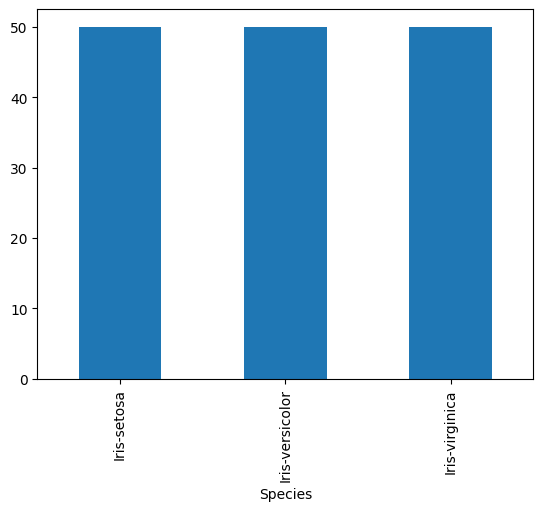

In [24]:
#répartition des espèces
import matplotlib.pyplot as plt

df["Species"].value_counts().plot(kind="bar")
plt.show()

([<matplotlib.patches.Wedge at 0x7efa37e65ee0>,
 [Text(0.5499999722395388, 0.9526279601903919, 'Iris-setosa'),
  Text(-1.0999999999999959, -9.616505800409723e-08, 'Iris-versicolor'),
  Text(0.5500003659264657, -0.9526277328950455, 'Iris-virginica')],
 [Text(0.29999998485793017, 0.5196152510129409, '33.33%'),
  Text(-0.5999999999999978, -5.2453668002234845e-08, '33.33%'),
  Text(0.30000019959625396, -0.5196151270336611, '33.33%')])

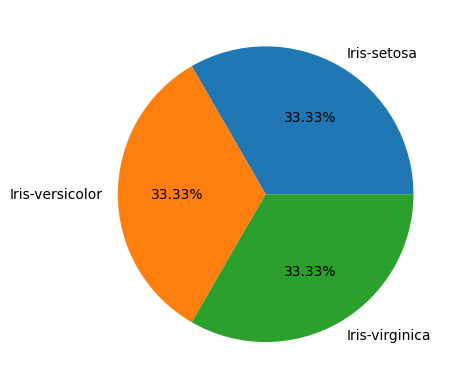

In [25]:
plt.pie(
    x=df['Species'].value_counts().values,
    labels=df['Species'].value_counts().index,
    autopct='%.2f%%'
        )

# Data preprocessing 

In [26]:
#Drop unnecessary columns
df.drop(columns=['Id'] , inplace=True)

In [27]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


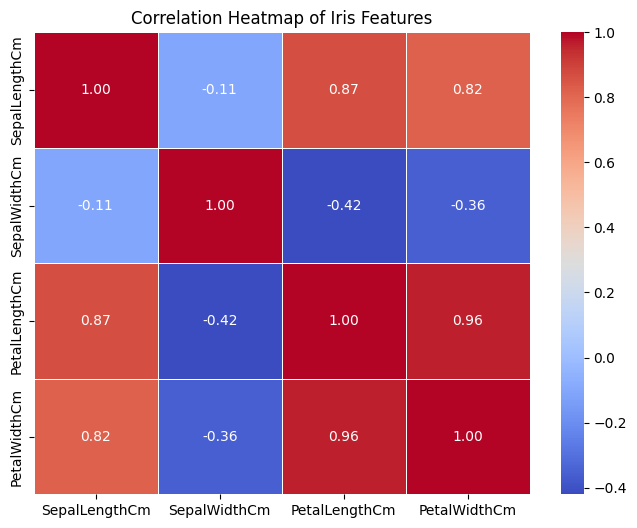

In [28]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical features
corr_matrix = X.corr()

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Iris Features")
plt.show()

The correlation heatmap indicates that Petal Length and Petal Width are highly correlated, while Sepal Width shows weaker correlations.

In [31]:
#separate the features from the target variable
X = df.drop(["Species"], axis=1)
y = df["Species"]

# Split Dataset into Train and Test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

# Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"{name}: {accuracy:.4f}")

In [ ]:
#import the evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
#evaluate all models in a loop:

results = []

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Compute metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Store the results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    # Display results
    print("=" * 50)
    print(f"Model: {name}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
#Display the comparison table
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy", ascending=False)

In [ ]:
#Plot the comparison
import matplotlib.pyplot as plt

results_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.ylim(0.8, 1.05)
plt.xticks(rotation=20)
plt.grid(axis="y")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

results_df




In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(results_df["Model"], results_df["Mean Accuracy"])

plt.title("5-Fold Cross-Validation Accuracy")
plt.xlabel("Model")
plt.ylabel("Mean Accuracy")
plt.ylim(0.9, 1.0)
plt.xticks(rotation=20)

plt.show()

In [ ]:
best_model = results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("Mean Accuracy:", round(best_model["Mean Accuracy"], 4))

#Why is Cross-Validation better?

Instead of evaluating the model on one single train-test split, 5-fold cross-validation:

Splits the dataset into 5 equal folds.
Trains the model 5 times.
Each fold is used once as the test set and four times as the training set.
Computes the accuracy for each fold.
Reports the mean accuracy and the standard deviation, providing a more reliable estimate of the model's performance.

# Predict new samples

In [ ]:
#Train the final model
from sklearn.linear_model import LogisticRegression

best_model = LogisticRegression(max_iter=200)

best_model.fit(X_train, y_train)

In [ ]:
#Predict a new flower
# New flower measurements
new_sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = best_model.predict(new_sample)

print("Predicted Species:", prediction[0])

In [ ]:
#Predict multiple flowers
new_samples = [
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [6.5, 3.0, 5.8, 2.2]
]

predictions = best_model.predict(new_samples)

for i, prediction in enumerate(predictions):
    print(f"Flower {i+1}: {prediction}")

# Conclusion

**Five classification algorithms were compared using 5-fold cross-validation: Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, Random Forest, and Support Vector Machine (SVM). Logistic Regression achieved the highest mean cross-validation accuracy of 97.33%, making it the best-performing model. It was therefore selected as the final classifier and used to predict the species of new Iris flowers based on their sepal and petal measurements. This demonstrates the model's ability to accurately classify previously unseen samples.**